In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

loading annotations into memory...
Done (t=20.08s)
creating index...
index created!


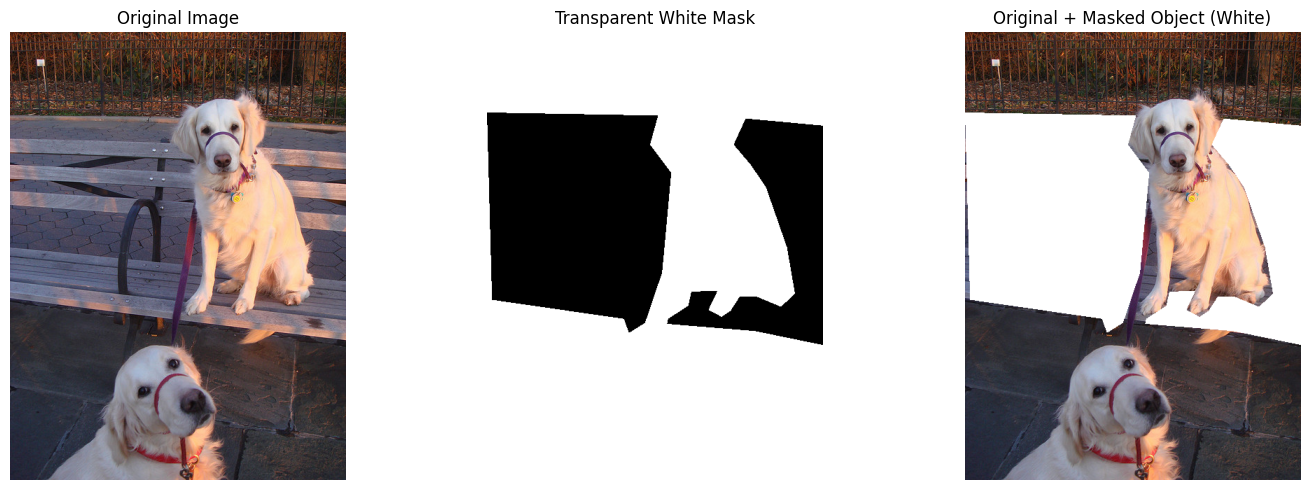

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO

# Set up the paths for the dataset
dataDir = '/kaggle/input/coco-2017-dataset/coco2017'
dataType = 'train2017'
annFile = os.path.join(dataDir, f'annotations/instances_{dataType}.json')
image_dir = os.path.join(dataDir, dataType)

# Initialize the COCO API
coco = COCO(annFile)

# Get all image IDs
imgIds = coco.getImgIds()

# Select a random image ID
imgId = random.choice(imgIds)
img_info = coco.loadImgs(imgId)[0]
img_path = os.path.join(image_dir, img_info['file_name'])

# Load the image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotation IDs for the selected image
annIds = coco.getAnnIds(imgIds=imgId, iscrowd=None)
anns = coco.loadAnns(annIds)

if not anns:
    print("No annotations found for this image. Please run the cell again to select another image.")
else:
    # Select a random annotation (object) from the image
    ann = random.choice(anns)

    # Load the mask for the selected annotation
    mask = coco.annToMask(ann)

    # Convert original image to RGBA (add alpha channel)
    image_rgba = cv2.cvtColor(image, cv2.COLOR_RGB2RGBA)

    # Create a transparent mask with a white object
    # The alpha channel is the mask itself, scaled to 255
    transparent_mask = np.zeros((*image.shape[:2], 4), dtype=np.uint8)
    transparent_mask[..., 3] = mask * 255  # Set alpha channel based on the mask

    # Combine the original image with the transparent mask
    # We use the alpha channel of the mask to blend it with the original image
    # The object pixels will have an alpha of 255, making them visible.
    # The background pixels will have an alpha of 0, making them transparent.
    combined_image = image_rgba.copy()
    combined_image[transparent_mask[..., 3] > 0] = [255, 255, 255, 255]

    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Transparent White Mask
    axes[1].imshow(transparent_mask)
    axes[1].set_title("Transparent White Mask")
    axes[1].axis('off')

    # Original + Masked Object with Transparency
    axes[2].imshow(combined_image)
    axes[2].set_title("Original + Masked Object (White)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

loading annotations into memory...
Done (t=19.95s)
creating index...
index created!


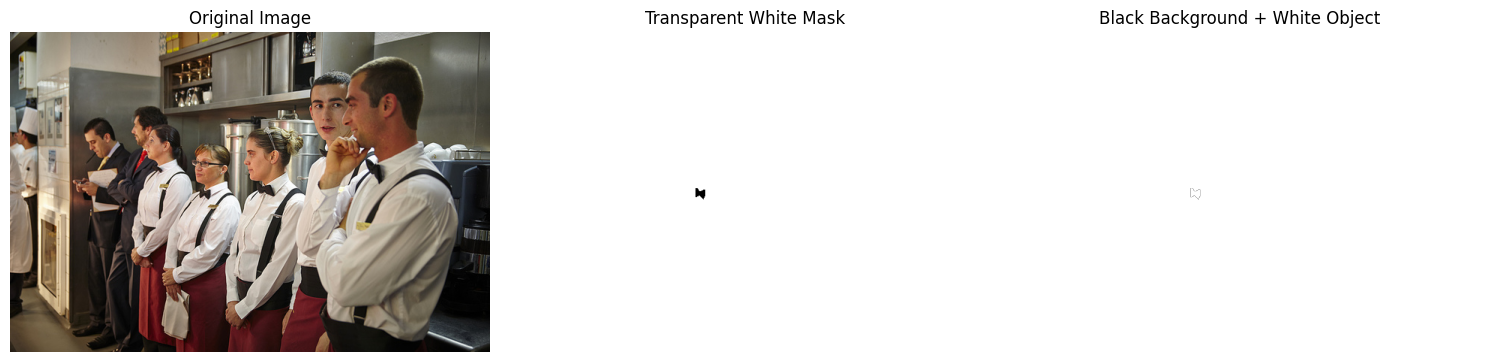

In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO

# Set up the paths for the dataset
dataDir = '/kaggle/input/coco-2017-dataset/coco2017'
dataType = 'train2017'
annFile = os.path.join(dataDir, f'annotations/instances_{dataType}.json')
image_dir = os.path.join(dataDir, dataType)

# Initialize the COCO API
coco = COCO(annFile)

# Get all image IDs
imgIds = coco.getImgIds()

# Select a random image ID
imgId = random.choice(imgIds)
img_info = coco.loadImgs(imgId)[0]
img_path = os.path.join(image_dir, img_info['file_name'])

# Load the image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotation IDs for the selected image
annIds = coco.getAnnIds(imgIds=imgId, iscrowd=None)
anns = coco.loadAnns(annIds)

if not anns:
    print("No annotations found for this image. Please run the cell again to select another image.")
else:
    # Select a random annotation (object) from the image
    ann = random.choice(anns)

    # Load the mask for the selected annotation
    mask = coco.annToMask(ann)

    # --- Changes for a black background and white object ---

    # Create a completely black RGBA background
    black_background_rgba = np.zeros((*image.shape[:2], 4), dtype=np.uint8)

    # Set the object pixels in the black background to white (R=255, G=255, B=255)
    # and also set their alpha channel to 255 (fully opaque)
    # The mask directly tells us where the object is (where mask == 1)
    object_pixels = (mask == 1)
    black_background_rgba[object_pixels, 0] = 255 # Red
    black_background_rgba[object_pixels, 1] = 255 # Green
    black_background_rgba[object_pixels, 2] = 255 # Blue
    black_background_rgba[object_pixels, 3] = 255 # Alpha (fully opaque)

    # --- End of changes ---

    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Transparent White Mask (still useful for showing the object's shape)
    # Create a transparent mask for display purposes
    transparent_mask_display = np.zeros((*image.shape[:2], 4), dtype=np.uint8)
    transparent_mask_display[..., 3] = mask * 255  # Alpha channel
    axes[1].imshow(transparent_mask_display)
    axes[1].set_title("Transparent White Mask")
    axes[1].axis('off')

    # Black Background + White Object
    axes[2].imshow(black_background_rgba)
    axes[2].set_title("Black Background + White Object")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

loading annotations into memory...
Done (t=17.80s)
creating index...
index created!


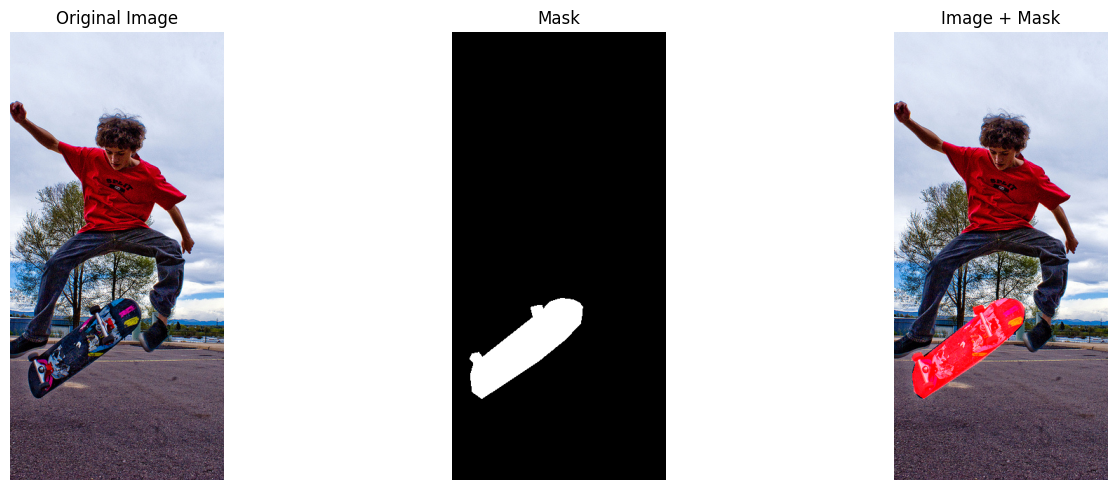

In [4]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO

# Set up the paths for the dataset
dataDir = '/kaggle/input/coco-2017-dataset/coco2017'
dataType = 'train2017'
annFile = os.path.join(dataDir, f'annotations/instances_{dataType}.json')
image_dir = os.path.join(dataDir, dataType)

# Initialize the COCO API
coco = COCO(annFile)

# Get all image IDs
imgIds = coco.getImgIds()

# Select a random image ID
imgId = random.choice(imgIds)
img_info = coco.loadImgs(imgId)[0]
img_path = os.path.join(image_dir, img_info['file_name'])

# Load the image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotation IDs for the selected image
annIds = coco.getAnnIds(imgIds=imgId, iscrowd=None)
anns = coco.loadAnns(annIds)

if not anns:
    print("No annotations found for this image. Please run the cell again to select another image.")
else:
    # Select a random annotation (object) from the image
    ann = random.choice(anns)

    # Load the mask for the selected annotation
    mask = coco.annToMask(ann)

    # Create the white mask for the middle plot
    white_mask = np.stack([mask, mask, mask], axis=-1) * 255

    # --- Creating the transparent color overlay for the third plot ---
    
    # Define the overlay color (e.g., red) and transparency (alpha)
    overlay_color = (255, 0, 0)  # Red
    alpha = 0.5  # 50% transparency

    # Convert the original image to RGBA
    image_rgba = cv2.cvtColor(image, cv2.COLOR_RGB2RGBA)
    
    # Create the overlay mask with the specified color and transparency
    overlay_mask_rgba = np.zeros_like(image_rgba)
    overlay_mask_rgba[mask == 1, :3] = overlay_color  # Set the color
    overlay_mask_rgba[mask == 1, 3] = int(255 * alpha)  # Set the transparency

    # Blend the original image and the transparent overlay
    # This is a key step. We use the alpha channel to blend the two images.
    blended_image = cv2.addWeighted(image_rgba, 1.0, overlay_mask_rgba, 1.0, 0)
    
    # Convert back to RGB for matplotlib display if needed
    blended_image_rgb = cv2.cvtColor(blended_image, cv2.COLOR_RGBA2RGB)

    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # White Mask
    axes[1].imshow(white_mask)
    axes[1].set_title("Mask")
    axes[1].axis('off')

    # Image + Masked Object with semi-transparent color
    axes[2].imshow(blended_image_rgb)
    axes[2].set_title("Image + Mask")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [1]:
# ============================================================
# 1. Import Libraries
# ============================================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from sklearn.metrics import jaccard_score
import cv2

# ============================================================
# 2. Dataset Paths
# ============================================================
DATA_ROOT = "/kaggle/input/coco-2017-dataset/coco2017"
IMG_DIR = os.path.join(DATA_ROOT, "train2017")
ANN_FILE = os.path.join(DATA_ROOT, "annotations/instances_train2017.json")

# ============================================================
# 3. Define Dataset Class
# ============================================================
class CocoSegDataset(Dataset):
    def __init__(self, coco, image_ids, img_dir, transform=None):
        self.coco = coco
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info["height"], img_info["width"]))
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# ============================================================
# 4. Load COCO Dataset
# ============================================================
coco = COCO(ANN_FILE)
image_ids = coco.getImgIds()[:200]  # small subset for fast training

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = CocoSegDataset(coco, image_ids, IMG_DIR, transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# ============================================================
# 5. Define U-Net Model
# ============================================================
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.down1 = conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bridge = conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.upconv2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.upconv1 = conv_block(128, 64)
        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)
        c2 = self.down2(p1)
        p2 = self.pool2(c2)
        b = self.bridge(p2)
        u2 = self.up2(b)
        u2 = torch.cat([u2, c2], dim=1)
        c_up2 = self.upconv2(u2)
        u1 = self.up1(c_up2)
        u1 = torch.cat([u1, c1], dim=1)
        c_up1 = self.upconv1(u1)
        return torch.sigmoid(self.out(c_up1))

# ============================================================
# 6. Training Setup
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ============================================================
# 7. Train for 5–10 Epochs
# ============================================================
for epoch in range(1, 6):  # train for 5 epochs
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch}/5] - Loss: {epoch_loss/len(train_loader):.4f}")

# ============================================================
# 8. Evaluation (IoU & Dice)
# ============================================================
def dice_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = (y_true * y_pred).sum()
    return (2. * intersection) / (y_true.sum() + y_pred.sum() + 1e-6)

ious, dices = [], []
model.eval()
os.makedirs("/kaggle/working/predictions", exist_ok=True)

with torch.no_grad():
    for i, (img, mask) in enumerate(val_loader):
        if i >= 5: break
        img, mask = img.to(device), mask.to(device)
        pred = (model(img) > 0.5).float()
        y_true = (mask.cpu().numpy().flatten() > 0.5).astype(np.uint8)
        y_pred = (pred.cpu().numpy().flatten() > 0.5).astype(np.uint8)
        iou = jaccard_score(y_true, y_pred)
        dice = dice_score(mask.cpu().numpy(), pred.cpu().numpy())
        ious.append(iou)
        dices.append(dice)

        plt.imsave(f"/kaggle/working/predictions/pred_{i+1}.png", pred.cpu().squeeze(), cmap='gray')
        print(f"Image {i+1}: IoU={iou:.3f}, Dice={dice:.3f}")

print(f"\nAverage IoU: {np.mean(ious):.3f}, Average Dice: {np.mean(dices):.3f}")


loading annotations into memory...
Done (t=22.82s)
creating index...
index created!
Epoch [1/5] - Loss: 0.6382
Epoch [2/5] - Loss: 0.5738
Epoch [3/5] - Loss: 0.5575
Epoch [4/5] - Loss: 0.5592
Epoch [5/5] - Loss: 0.5512
Image 1: IoU=0.000, Dice=0.000
Image 2: IoU=0.000, Dice=0.000
Image 3: IoU=0.000, Dice=0.000
Image 4: IoU=0.000, Dice=0.000
Image 5: IoU=0.000, Dice=0.000

Average IoU: 0.000, Average Dice: 0.000


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input", topdown=True):
    print(root)
    # stop after first few results
    if 'train' in root.lower() or 'images' in root.lower():
        break


/kaggle/input
/kaggle/input/coco-2017-dataset
/kaggle/input/coco-2017-dataset/coco2017
/kaggle/input/coco-2017-dataset/coco2017/val2017
/kaggle/input/coco-2017-dataset/coco2017/annotations
/kaggle/input/coco-2017-dataset/coco2017/test2017
/kaggle/input/coco-2017-dataset/coco2017/train2017
